In [3]:
import pandas as pd

# 1. Load the dataset using the correct filename
df = pd.read_csv('saudi_aramco_data.csv')

# 2. Display the first 5 rows of the dataset
print("--- First 5 Rows of the Dataset ---")
display(df.head())

# 3. Get structural information (Data types and missing values)
print("\n--- Dataset Structural Information ---")
df.info()

--- First 5 Rows of the Dataset ---


,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-12-11,29.090908,29.090908,29.090908,29.090908,24.556959,38289394
1,2019-12-12,31.983471,31.983471,29.752066,30.413223,25.673187,505692621
2,2019-12-15,30.661158,30.991735,30.413223,30.909090,26.091770,98349281
3,2019-12-16,30.991735,31.487602,30.991735,31.404959,26.510353,105973907
4,2019-12-17,31.446280,31.528925,30.991735,31.198347,26.335951,142672245



--- Dataset Structural Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1164 entries, 0 to 1163
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1164 non-null   object 
 1   Open       1164 non-null   float64
 2   High       1164 non-null   float64
 3   Low        1164 non-null   float64
 4   Close      1164 non-null   float64
 5   Adj Close  1164 non-null   float64
 6   Volume     1164 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 63.8+ KB


In [4]:
# 1. Convert 'Date' column from string to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# 2. Set 'Date' column as the index of the DataFrame
df.set_index('Date', inplace=True)

# 3. Sort the DataFrame chronologically (oldest to newest)
df.sort_index(inplace=True)

# 4. Programmatically verify if there are any missing (null) values
print("--- Missing Values Count per Column ---")
print(df.isnull().sum())

# 5. Display the updated structure to verify changes
print("\n--- Updated Dataset Structural Information ---")
df.info()

print("\n--- Preview of the Prepared Data ---")
display(df.head())

--- Missing Values Count per Column ---
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

--- Updated Dataset Structural Information ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1164 entries, 2019-12-11 to 2024-08-14
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1164 non-null   float64
 1   High       1164 non-null   float64
 2   Low        1164 non-null   float64
 3   Close      1164 non-null   float64
 4   Adj Close  1164 non-null   float64
 5   Volume     1164 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 63.7 KB

--- Preview of the Prepared Data ---


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2019-12-11,29.090908,29.090908,29.090908,29.090908,24.556959,38289394
2019-12-12,31.983471,31.983471,29.752066,30.413223,25.673187,505692621
2019-12-15,30.661158,30.991735,30.413223,30.909090,26.091770,98349281
2019-12-16,30.991735,31.487602,30.991735,31.404959,26.510353,105973907
2019-12-17,31.446280,31.528925,30.991735,31.198347,26.335951,142672245


Matplotlib is building the font cache; this may take a moment.


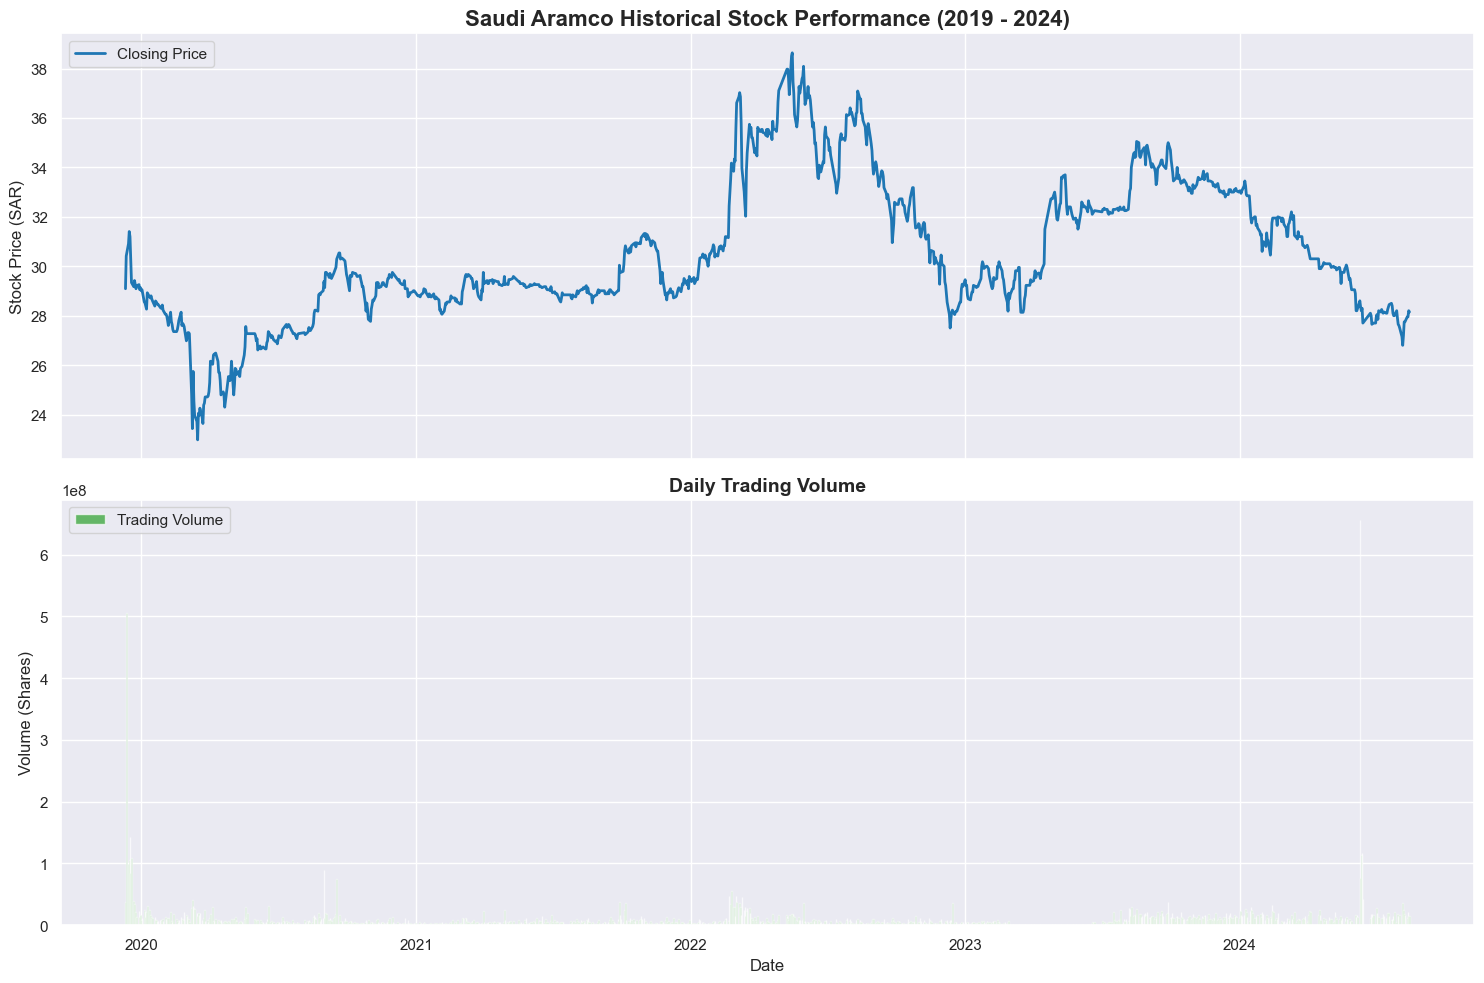

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plots
sns.set_theme(style="darkgrid")

# Create a figure with 2 subplots (Vertical stack)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# 1. Plot the Closing Price
ax1.plot(df.index, df['Close'], color='tab:blue', linewidth=2, label='Closing Price')
ax1.set_title('Saudi Aramco Historical Stock Performance (2019 - 2024)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Stock Price (SAR)', fontsize=12)
ax1.legend(loc='upper left')

# 2. Plot the Trading Volume
ax2.bar(df.index, df['Volume'], color='tab:green', alpha=0.7, label='Trading Volume')
ax2.set_title('Daily Trading Volume', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Volume (Shares)', fontsize=12)
ax2.legend(loc='upper left')

# Adjust layout and save the plot for GitHub repository documentation
plt.tight_layout()
plt.savefig('aramco_market_performance.png', dpi=300)

# Display the charts
plt.show()

In [6]:
# 1. Calculate Technical Indicators
# SMA 50: Short-term trend indicator
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# SMA 200: Long-term trend indicator
df['SMA_200'] = df['Close'].rolling(window=200).mean()

# 2. Calculate Daily Percentage Returns for Risk Analysis
df['Daily_Return'] = df['Close'].pct_change()

# 3. Preview the dataset with the new financial metrics
print("--- Dataset Snapshot with Financial Indicators ---")
display(df[['Close', 'SMA_50', 'SMA_200', 'Daily_Return']].tail(10))

# 4. Generate basic statistical summaries for risk and return
print("\n--- Summary Statistics for Daily Returns (Risk Analysis) ---")
print(df['Daily_Return'].describe())

--- Dataset Snapshot with Financial Indicators ---


,Close,SMA_50,SMA_200,Daily_Return
Date,,,,
2024-08-01,27.500000,28.411,31.10800,-0.003623
2024-08-04,27.150000,28.359,31.07600,-0.012727
2024-08-05,26.799999,28.297,31.04150,-0.012891
2024-08-06,27.200001,28.242,31.01075,0.014925
2024-08-07,27.750000,28.196,30.98250,0.020221
2024-08-08,27.750000,28.152,30.95400,0.000000
2024-08-11,27.950001,28.122,30.92675,0.007207
2024-08-12,27.950001,28.091,30.89900,0.000000
2024-08-13,28.200001,28.070,30.87325,0.008945



--- Summary Statistics for Daily Returns (Risk Analysis) ---
count    1163.000000
mean        0.000034
std         0.011146
min        -0.090909
25%        -0.004354
50%         0.000000
75%         0.004231
max         0.098765
Name: Daily_Return, dtype: float64


In [ ]:
# Save the enriched DataFrame with all calculated indicators into a new CSV file
# We keep index=True because 'Date' is our index and we need it as a column in Tableau
df.to_csv('saudi_aramco_enriched_data.csv', index=True)

print("Success! 'saudi_aramco_enriched_data.csv' has been created and is ready for Tableau.")


Success! 'saudi_aramco_enriched_data.csv' has been created and is ready for Tableau.
